# **Read CKPT**

In [2]:
import torch
import json

# 读取 .pt 文件
pt_path = "/lvs0/rccs-hpbdrt/minqiu/ZO_ckpt_New/20-SST2-Qwen3-1.7B-mezo-ft-1e-5-1e-3-0/checkpoint-100/optimizer.pt"
pt_path1 = "/lvs0/rccs-hpbdrt/minqiu/ZO_ckpt_New/21-SST2-Qwen3-1.7B-mezo-ft-1e-5-1e-3-0/checkpoint-100/optimizer.pt"
meta = torch.load(pt_path, map_location='cpu', weights_only=True)
meta1 = torch.load(pt_path1, map_location='cpu', weights_only=True)
print("=== optimizer1 ===")
print(meta)
print("=== optimizer_ori ===")
print(meta1)

# # 读取 .json 文件
# json_path = "/lvs0/rccs-hpbdrt/minqiu/ZO_ckpt/Test_staging_4-SST2-Qwen3-1.7B-mezo-ft-1e-6-1e-4-0/checkpoint-200/zo_replay_history.json"
# with open(json_path, 'r') as f:
#     history = json.load(f)
# print("\n=== zo_replay_history.json ===")
# print(history)

=== optimizer1 ===
{'state': {}, 'param_groups': [{'lr': 1e-05, 'weight_decay': 0.0, 'maximize': False, 'foreach': None, 'differentiable': False, 'fused': None, 'initial_lr': 1e-05, 'params': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 18

In [ ]:
import os
from safetensors.torch import load_file

path = "/home/ubuntu/.cache/huggingface/hub/models--Qwen--Qwen3-1.7B/snapshots/70d244cc86ccca08cf5af4e1e306ecf908b1ad5e/model-00001-of-00002.safetensors"
assert os.path.exists(path), f"File not found: {path}"

state = load_file(path)  # dict: name -> torch.Tensor

print("Loaded:", path)
print("Num tensors:", len(state))

# Show a quick summary (first ~40 tensors)
for i, (k, v) in enumerate(state.items()):
    print(f"{i:03d}  {k:60s}  shape={tuple(v.shape)}  dtype={v.dtype}  device={v.device}")

In [ ]:
import torch
from safetensors.torch import load_file

state = load_file(path)
path1 = "/home/ubuntu/.cache/huggingface/hub/models--Qwen--Qwen3-1.7B/snapshots/70d244cc86ccca08cf5af4e1e306ecf908b1ad5e/model-00002-of-00002.safetensors"
state1 = load_file(path1)

w_lm = state1["lm_head.weight"]
w_emb = state["model.embed_tokens.weight"]

print("lm_head.weight:", tuple(w_lm.shape), w_lm.dtype, w_lm.device)
print("model.embed_tokens.weight:", tuple(w_emb.shape), w_emb.dtype, w_emb.device)

same_shape = (w_lm.shape == w_emb.shape)
same_dtype = (w_lm.dtype == w_emb.dtype)

# exact equality + closeness
exact_equal = torch.equal(w_lm, w_emb)
max_abs_diff = (w_lm - w_emb).abs().max().item() if same_shape else None
allclose = torch.allclose(w_lm, w_emb, rtol=0.0, atol=0.0) if same_shape else False

print("\nSame shape:", same_shape)
print("Same dtype:", same_dtype)
print("torch.equal:", exact_equal)
print("max|diff|:", max_abs_diff)
print("allclose(atol=0, rtol=0):", allclose)

# If you want a more tolerant check too:
if same_shape:
    print("allclose(atol=1e-6, rtol=1e-6):", torch.allclose(w_lm, w_emb, atol=1e-6, rtol=1e-6))

# **Calculation**

# Soft Failure Overhead Model — Async Mode

Solves for optimal K* (anchor interval) with N*(K) substituted in.

**Variables**
| Variable | Meaning |
|----------|---------|
| K | anchor interval (steps) — to optimize |
| N | CPU shadow checkpoint interval — to optimize |
| t_step | GPU single-step training time |
| t_l | single-step log write time |
| t | t_step + t_l |
| t_d2h | anchor GPU→CPU transfer time (blocks training) |
| t_r | GPU single-step replay time |
| t_rc | CPU single-step replay time |
| t_cp | CPU shadow checkpoint time (blocks CPU replay) |
| r_replay(N) | CPU shadow effective speed ratio = Nt / (N*t_rc + t_cp) |
| L_cpu | load CPU shadow checkpoint → GPU time |
| M | mean steps between failures = MTBF_hours * 3600 / t |
| T_cycle | Kt + t_d2h |
| alpha | sqrt(K * t * t_cp) |
| N*(K) | (alpha - t_cp) / t_rc |

**overhead(K)**

$$\text{overhead}(K) = \underbrace{\frac{Kt_l + t_{d2h}}{T_{cycle}}}_{\text{checkpoint frequency cost}} + \underbrace{\frac{1}{M}\left(L_{cpu} + \frac{F(K)}{2T_{cycle}}\right)}_{\text{failure recovery cost}}$$

where:
$$F(K) = K(t_r - t)(T_{cycle} + t_{d2h}) + \alpha(2T_{cycle} + t_{d2h}) - t_{cp} T_{cycle} - t_{d2h}^2$$


$$P'(K) = \frac{-t_{d2h} \cdot t_{step}}{T_{cycle}^2}$$

$$Q'(K) = \frac{F'T_{cycle} - Ft}{2M \cdot T_{cycle}^2}$$

where:
$$F' = 2(t_r - t)T_{cycle} + \frac{t \cdot t_{cp}}{2\alpha}(2Kt + 3t_{d2h}) + 2\alpha t - t_{cp} t$$


$$P'(K) = \frac{-t_{d2h} \cdot t_{step}}{T_{cycle}^2}$$

$$Q'(K) = \frac{F'T_{cycle} - Ft}{2M \cdot T_{cycle}^2}$$

where:
$$F' = 2(t_r - t)T_{cycle} + \frac{t \cdot t_{cp}}{2\alpha}(2Kt + 3t_{d2h}) + 2\alpha t - t_{cp} t$$

t = t_step + t_l = 0.65408
M = 38527 steps (MTBF = 7.0 h)
Method 1 (minimize_scalar):
  K*           = 4016.03
  overhead(K*) = 0.00269760
Method 2 (brentq on numerical derivative):
  K*           = 4016.03
  overhead(K*) = 0.00269760
Optimal solution:
  K*       = 4016.03 steps
  N*       = 120.09 steps
  r_replay = 0.7569
  T_cycle  = 2628.81 s
  overhead = 0.2698 %

Key distinction:
  t_rc (CPU replay) = 0.83 s  — used in r_replay, N*
  t_r  (GPU replay) = 0.06 s   — used in recovery time


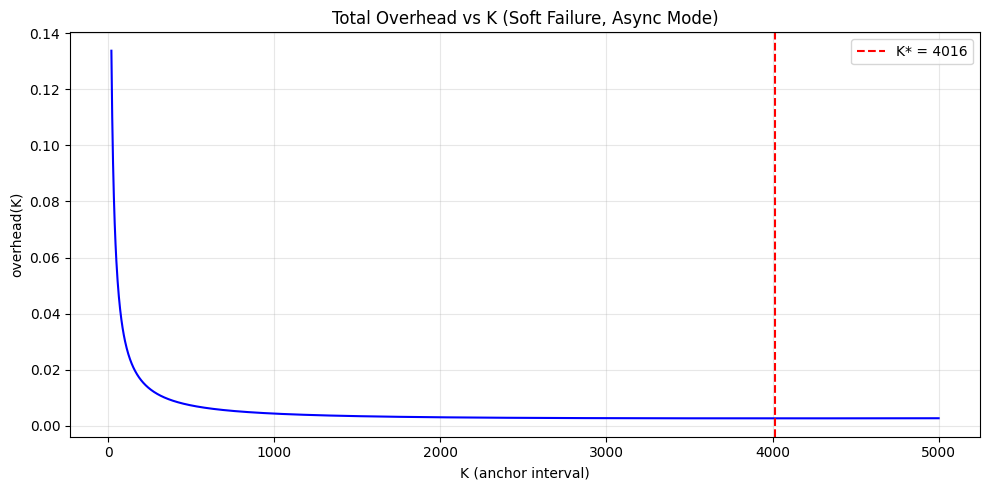

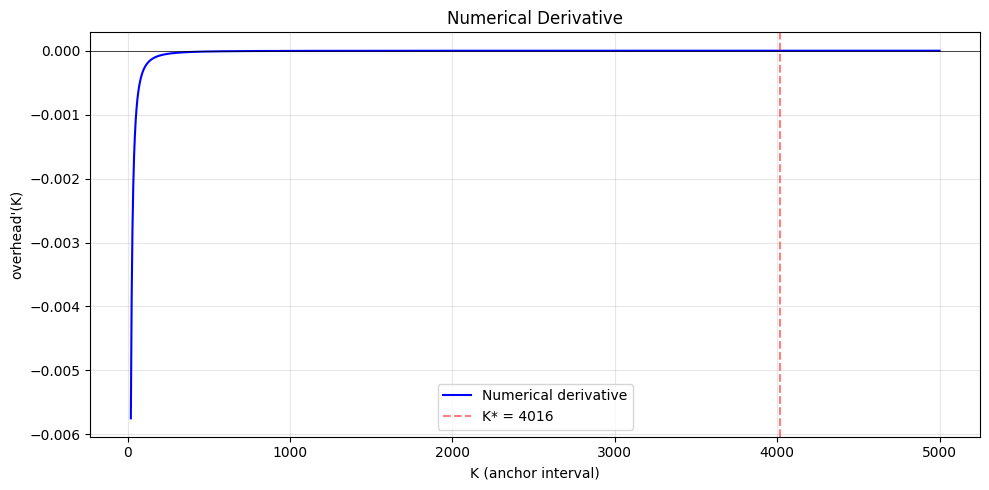

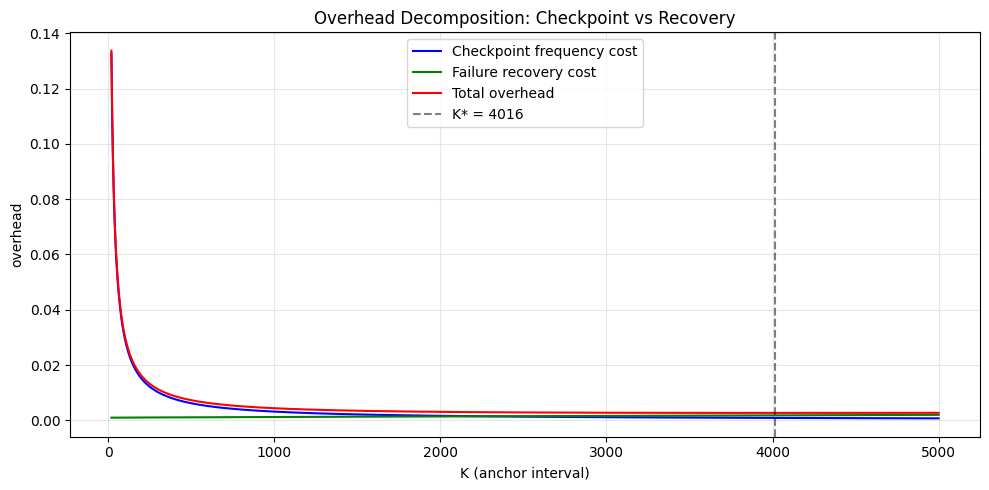

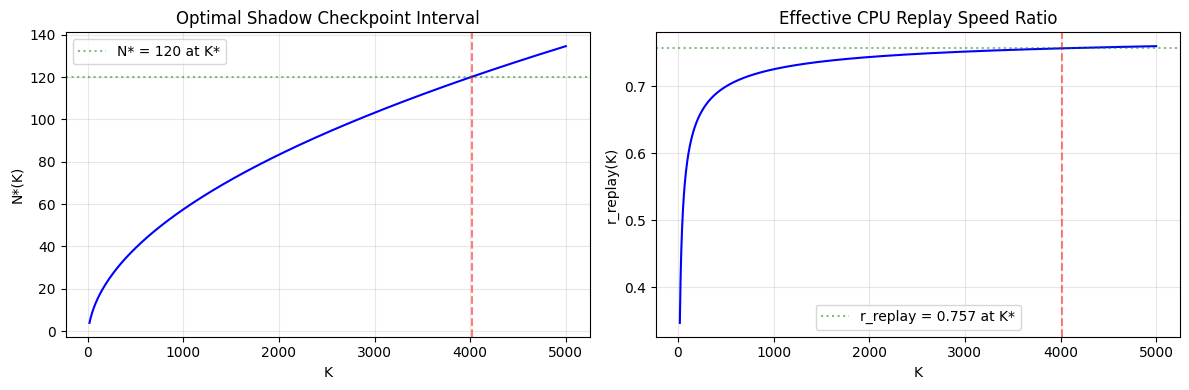

In [7]:
# Parameters

import numpy as np
from scipy.optimize import minimize_scalar, brentq
import matplotlib.pyplot as plt

# Hardware parameters (placeholder values — replace with real)
t_step   = 0.654       # GPU single-step training time (s)
t_l      = 8e-5     # log write time per step (s)
t        = t_step + t_l

t_d2h    = 2.0       # anchor D2H time (s)

t_r      = 0.06       # GPU single-step replay time (s)
t_rc     = 0.830       # CPU single-step replay time (s)
t_cp     = 4.1       # CPU shadow checkpoint time (s)

L_cpu    = 36.999       # load from CPU shadow to GPU (s)

MTBF_hours = 7.0     # mean time between failures (hours)
M = MTBF_hours * 3600 / t  # convert to steps

print(f"t = t_step + t_l = {t}")
print(f"M = {M:.0f} steps (MTBF = {MTBF_hours} h)")

# Core computations

def compute_N_star(K):
    """Optimal CPU shadow checkpoint interval. Uses t_rc."""
    alpha = np.sqrt(K * t * t_cp)
    return (alpha - t_cp) / t_rc

def compute_r_replay(N):
    """CPU shadow effective speed ratio. Uses t_rc."""
    return N * t / (N * t_rc + t_cp)

# overhead(K) — exact, no approximation

def overhead(K):
    """Total per-step overhead as a fraction of cycle time."""
    T_cycle = K * t + t_d2h

    # N*(K) — must be positive
    N_star = compute_N_star(K)
    if N_star <= 0:
        return np.inf

    r_replay = compute_r_replay(N_star)

    # Replay distance (steps) for each crash phase
    D_train = (1 - r_replay) * K / 2 + N_star / 2
    D_d2h   = (1 - r_replay) * K + N_star / 2 - t_d2h / (2 * t_rc)

    # Recovery time = load + GPU_replay_time * distance
    E_train = L_cpu + t_r * D_train
    E_d2h   = L_cpu + t_r * D_d2h

    # Weighted expectation
    E_recover = (K * t / T_cycle) * E_train + (t_d2h / T_cycle) * E_d2h

    # checkpoint frequency cost
    ckpt_cost = (K * t_l + t_d2h) / T_cycle

    # failure recovery cost
    recover_cost = E_recover / M

    return ckpt_cost + recover_cost

# overhead'(K) — numerical only
def overhead_deriv_numerical(K, h=1e-4):
    """Central difference numerical derivative."""
    return (overhead(K + h) - overhead(K - h)) / (2 * h)

# Solve for K* — Method 1: minimize_scalar

K_min_bound = t_cp**2 / (t * t_cp) + 1  # N* > 0 requires K > t_cp / t
K_max_bound = M

result1 = minimize_scalar(overhead, bounds=(K_min_bound, K_max_bound), method='bounded')
K_star_method1 = result1.x

print(f"Method 1 (minimize_scalar):")
print(f"  K*           = {K_star_method1:.2f}")
print(f"  overhead(K*) = {result1.fun:.8f}")

# Solve for K* — Method 2: brentq on numerical derivative

K_test = np.logspace(np.log10(max(10, K_min_bound)), np.log10(K_max_bound), 1000)
derivs = [overhead_deriv_numerical(K) for K in K_test]

K_star_method2 = None
for i in range(len(derivs) - 1):
    if derivs[i] * derivs[i + 1] < 0:
        K_star_method2 = brentq(overhead_deriv_numerical, K_test[i], K_test[i + 1])
        break

if K_star_method2 is not None:
    print(f"Method 2 (brentq on numerical derivative):")
    print(f"  K*           = {K_star_method2:.2f}")
    print(f"  overhead(K*) = {overhead(K_star_method2):.8f}")
else:
    print("Method 2: No sign change found in derivative.")

# Summary at optimal K*

K_star = K_star_method1
T_cycle_star = K_star * t + t_d2h
N_star = compute_N_star(K_star)
r_replay_star = compute_r_replay(N_star)

print(f"Optimal solution:")
print(f"  K*       = {K_star:.2f} steps")
print(f"  N*       = {N_star:.2f} steps")
print(f"  r_replay = {r_replay_star:.4f}")
print(f"  T_cycle  = {T_cycle_star:.2f} s")
print(f"  overhead = {overhead(K_star)*100:.4f} %")
print(f"")
print(f"Key distinction:")
print(f"  t_rc (CPU replay) = {t_rc} s  — used in r_replay, N*")
print(f"  t_r  (GPU replay) = {t_r} s   — used in recovery time")

# Plot 1: overhead(K)

K_range = np.linspace(max(20, K_min_bound), min(5000, K_max_bound), 2000)
oh_values = [overhead(K) for K in K_range]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(K_range, oh_values, 'b-', linewidth=1.5)
ax.axvline(K_star, color='r', linestyle='--', label=f'K* = {K_star:.0f}')
ax.set_xlabel('K (anchor interval)')
ax.set_ylabel('overhead(K)')
ax.set_title('Total Overhead vs K (Soft Failure, Async Mode)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Numerical derivative

deriv_numeric = [overhead_deriv_numerical(K) for K in K_range]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(K_range, deriv_numeric, 'b-', linewidth=1.5, label='Numerical derivative')
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(K_star, color='r', linestyle='--', alpha=0.5, label=f'K* = {K_star:.0f}')
ax.set_xlabel('K (anchor interval)')
ax.set_ylabel("overhead'(K)")
ax.set_title('Numerical Derivative')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: Decomposed overhead — checkpoint cost vs recovery cost

def overhead_decomposed(K):
    """Return (ckpt_cost, recover_cost) separately."""
    T_cycle = K * t + t_d2h
    N_star = compute_N_star(K)
    if N_star <= 0:
        return np.inf, np.inf
    r_replay = compute_r_replay(N_star)

    D_train = (1 - r_replay) * K / 2 + N_star / 2
    D_d2h   = (1 - r_replay) * K + N_star / 2 - t_d2h / (2 * t_rc)

    E_train = L_cpu + t_r * D_train
    E_d2h   = L_cpu + t_r * D_d2h

    E_recover = (K * t / T_cycle) * E_train + (t_d2h / T_cycle) * E_d2h

    ckpt_cost = (K * t_l + t_d2h) / T_cycle
    recover_cost = E_recover / M
    return ckpt_cost, recover_cost


ckpt_costs = []
recover_costs = []
for K in K_range:
    c, r = overhead_decomposed(K)
    ckpt_costs.append(c)
    recover_costs.append(r)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(K_range, ckpt_costs, 'b-', linewidth=1.5, label='Checkpoint frequency cost')
ax.plot(K_range, recover_costs, 'g-', linewidth=1.5, label='Failure recovery cost')
ax.plot(K_range, oh_values, 'r-', linewidth=1.5, label='Total overhead')
ax.axvline(K_star, color='k', linestyle='--', alpha=0.5, label=f'K* = {K_star:.0f}')
ax.set_xlabel('K (anchor interval)')
ax.set_ylabel('overhead')
ax.set_title('Overhead Decomposition: Checkpoint vs Recovery')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 4: N*(K) and r_replay(K) as functions of K

N_stars = []
r_replays = []
for K in K_range:
    N_s = compute_N_star(K)
    N_stars.append(N_s)
    if N_s > 0:
        r_replays.append(compute_r_replay(N_s))
    else:
        r_replays.append(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_range, N_stars, 'b-', linewidth=1.5)
ax1.axvline(K_star, color='r', linestyle='--', alpha=0.5)
ax1.axhline(N_star, color='g', linestyle=':', alpha=0.5, label=f'N* = {N_star:.0f} at K*')
ax1.set_xlabel('K')
ax1.set_ylabel('N*(K)')
ax1.set_title('Optimal Shadow Checkpoint Interval')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(K_range, r_replays, 'b-', linewidth=1.5)
ax2.axvline(K_star, color='r', linestyle='--', alpha=0.5)
ax2.axhline(r_replay_star, color='g', linestyle=':', alpha=0.5, label=f'r_replay = {r_replay_star:.3f} at K*')
ax2.set_xlabel('K')
ax2.set_ylabel('r_replay(K)')
ax2.set_title('Effective CPU Replay Speed Ratio')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Hard Failure Overhead Model — Async Mode

Solves for optimal K* (anchor interval) for hard failure scenario.

**Variables**
| Variable | Meaning |
|----------|---------|
| K | anchor interval (steps) — to optimize |
| t_step | GPU single-step training time |
| t_l | single-step log write time |
| t | t_step + t_l |
| t_d2h | anchor GPU→CPU transfer time (blocks training) |
| t_persist | anchor CPU→disk write time (async, background) |
| n_p | persist期间GPU训练步数 = t_persist / t_step |
| t_r | CPU single-step replay time |
| L_disk | load disk anchor → GPU time |
| M | mean steps between failures = MTBF_hours * 3600 / t |
| T_cycle | Kt + t_d2h |


**overhead(K)**

$$\text{overhead}^{hard}(K) = \underbrace{\frac{Kt_l + t_{d2h}}{T_{cycle}}}_{\text{checkpoint frequency cost}} + \underbrace{\frac{E[T_{recover}^{hard}]}{M}}_{\text{failure recovery cost}}$$

$$E[T_{recover}^{hard}] = \frac{Kt}{T_{cycle}}\left(L_{disk} + t_r\left(n_p + \frac{K}{2}\right)\right) + \frac{t_{d2h}}{T_{cycle}}\left(L_{disk} + t_r K\right)$$

**overhead'(K) — exact derivative**

Using $G(K)/T_{cycle}$ form where:
$$G(K) = \frac{t_r t}{2}K^2 + K(tA + t_{d2h}t_r) + t_{d2h}L_{disk}$$
$$G'(K) = t_r t K + tA + t_{d2h}t_r$$
$$A = L_{disk} + t_r n_p$$

$$P'(K) = \frac{-t_{d2h} \cdot t_{step}}{T_{cycle}^2}$$
$$Q'(K) = \frac{G'T_{cycle} - Gt}{M \cdot T_{cycle}^2}$$

t = t_step + t_l = 0.65408
n_p = t_persist / t_step = 35.16819571865443
K_min_async = 36
M = 38527 steps (MTBF = 7.0 h)
Method 1 (minimize_scalar):
  K*           = 1978.40
  overhead(K*) = 0.00427773
Method 2 (brentq on derivative):
  K*           = 1978.40
  overhead(K*) = 0.00427773
  overhead'(K*)= -1.06e-22
Derivative validation at K* = 1978.40:
  Analytic:  4.11e-16
  Numerical: 0.00e+00
Optimal solution:
  K*       = 1978.40 steps
  T_cycle  = 1296.03 s
  n_p      = 35.17 steps
  overhead = 0.4278 %


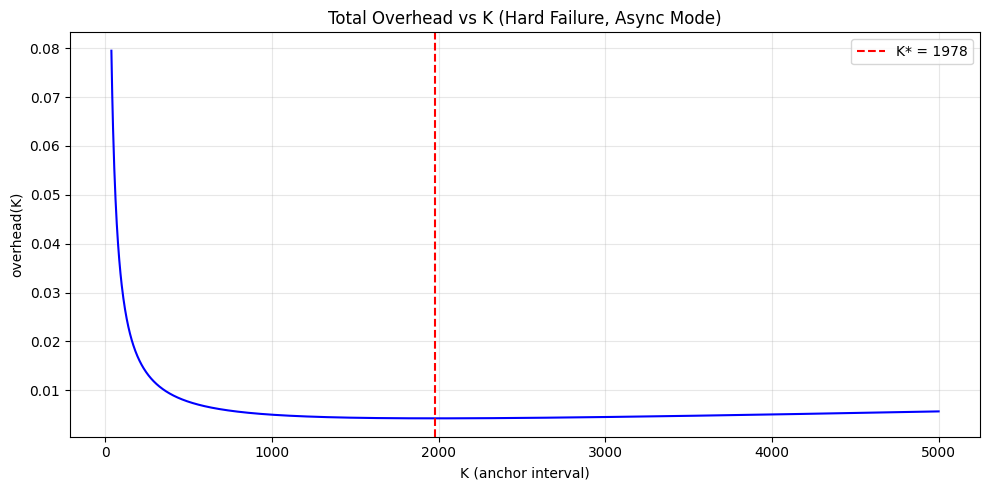

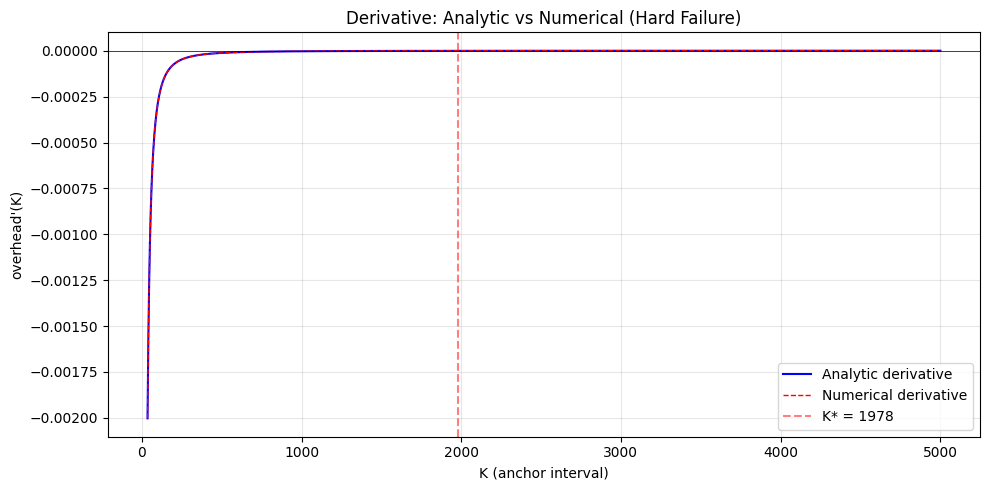

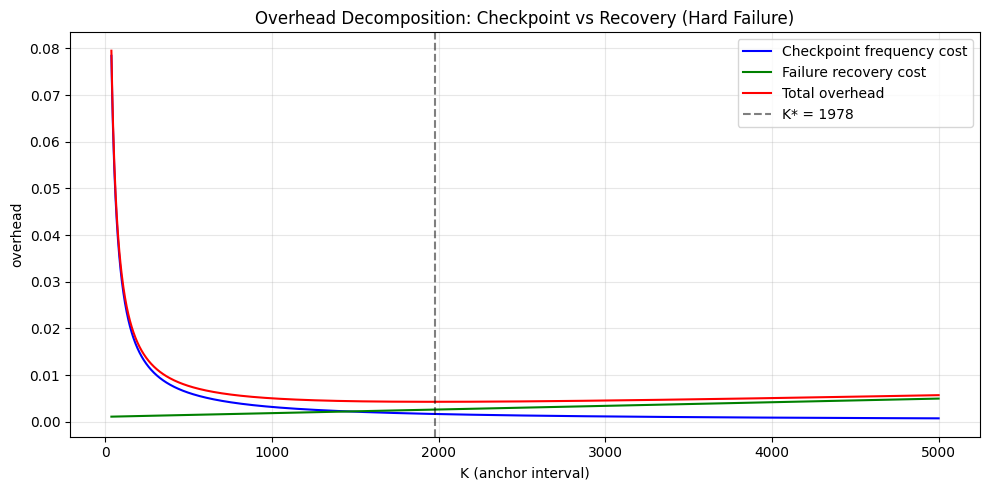

In [9]:
# Parameters
import numpy as np
from scipy.optimize import minimize_scalar, brentq
import matplotlib.pyplot as plt

# Hardware parameters (placeholder values — replace with real)
t_step    = 0.654       # GPU single-step training time (s)
t_l       = 8e-5     # log write time per step (s)
t         = t_step + t_l

t_d2h     = 2.0       # anchor D2H time (s)
t_persist = 23.0       # anchor CPU→disk write time (s)
n_p       = t_persist / t_step  # persist期间GPU训练步数

t_r       = 0.06       # GPU single-step replay time (s)

L_disk    = 39.1      # load from disk to GPU (s)

MTBF_hours = 7.0      # mean time between failures (hours)
M = MTBF_hours * 3600 / t  # convert to steps

# Async minimum K
K_min_async = int(np.ceil(n_p))

print(f"t = t_step + t_l = {t}")
print(f"n_p = t_persist / t_step = {n_p}")
print(f"K_min_async = {K_min_async}")
print(f"M = {M:.0f} steps (MTBF = {MTBF_hours} h)")


def overhead_hard(K):
    """Total per-step overhead for hard failure model."""
    T_cycle = K * t + t_d2h

    # E[T_recover^hard]
    E_train = L_disk + t_r * (n_p + K / 2)
    E_d2h   = L_disk + t_r * K

    E_recover = (K * t / T_cycle) * E_train + (t_d2h / T_cycle) * E_d2h

    # checkpoint frequency cost
    ckpt_cost = (K * t_l + t_d2h) / T_cycle

    # failure recovery cost
    recover_cost = E_recover / M

    return ckpt_cost + recover_cost


A = L_disk + t_r * n_p  # constant

def overhead_hard_deriv(K):
    """Exact derivative d(overhead^hard)/dK."""
    T_cycle = K * t + t_d2h

    # P'(K)
    P_prime = -t_d2h * t_step / T_cycle**2

    # G(K) and G'(K)
    G = (t_r * t / 2) * K**2 + K * (t * A + t_d2h * t_r) + t_d2h * L_disk
    G_prime = t_r * t * K + t * A + t_d2h * t_r

    # Q'(K)
    Q_prime = (G_prime * T_cycle - G * t) / (M * T_cycle**2)

    return P_prime + Q_prime


def overhead_hard_deriv_numerical(K, h=1e-4):
    """Central difference numerical derivative for verification."""
    return (overhead_hard(K + h) - overhead_hard(K - h)) / (2 * h)


# Solve for K* — Method 1: minimize_scalar
K_max_bound = M

result1 = minimize_scalar(overhead_hard, bounds=(K_min_async, K_max_bound), method='bounded')
K_star_method1 = result1.x

print(f"Method 1 (minimize_scalar):")
print(f"  K*           = {K_star_method1:.2f}")
print(f"  overhead(K*) = {result1.fun:.8f}")

# Solve for K* — Method 2: brentq on derivative
K_test = np.logspace(np.log10(max(K_min_async, 10)), np.log10(K_max_bound), 1000)
derivs = [overhead_hard_deriv(K) for K in K_test]

K_star_method2 = None
for i in range(len(derivs) - 1):
    if derivs[i] * derivs[i + 1] < 0:
        K_star_method2 = brentq(overhead_hard_deriv, K_test[i], K_test[i + 1])
        break

if K_star_method2 is not None:
    print(f"Method 2 (brentq on derivative):")
    print(f"  K*           = {K_star_method2:.2f}")
    print(f"  overhead(K*) = {overhead_hard(K_star_method2):.8f}")
    print(f"  overhead'(K*)= {overhead_hard_deriv(K_star_method2):.2e}")
else:
    print("Method 2: No sign change found in derivative.")

# Cross-validate: analytic vs numerical derivative at K*

print(f"Derivative validation at K* = {K_star_method1:.2f}:")
print(f"  Analytic:  {overhead_hard_deriv(K_star_method1):.2e}")
print(f"  Numerical: {overhead_hard_deriv_numerical(K_star_method1):.2e}")

# Summary at optimal K*

K_star = K_star_method1
T_cycle_star = K_star * t + t_d2h

print(f"Optimal solution:")
print(f"  K*       = {K_star:.2f} steps")
print(f"  T_cycle  = {T_cycle_star:.2f} s")
print(f"  n_p      = {n_p:.2f} steps")
print(f"  overhead = {overhead_hard(K_star)*100:.4f} %")

# Plot 1: overhead(K)

K_range = np.linspace(K_min_async, min(5000, K_max_bound), 2000)
oh_values = [overhead_hard(K) for K in K_range]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(K_range, oh_values, 'b-', linewidth=1.5)
ax.axvline(K_star, color='r', linestyle='--', label=f'K* = {K_star:.0f}')
ax.set_xlabel('K (anchor interval)')
ax.set_ylabel('overhead(K)')
ax.set_title('Total Overhead vs K (Hard Failure, Async Mode)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Derivative — analytic vs numerical

deriv_analytic = [overhead_hard_deriv(K) for K in K_range]
deriv_numeric = [overhead_hard_deriv_numerical(K) for K in K_range]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(K_range, deriv_analytic, 'b-', linewidth=1.5, label='Analytic derivative')
ax.plot(K_range, deriv_numeric, 'r--', linewidth=1.0, label='Numerical derivative')
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(K_star, color='r', linestyle='--', alpha=0.5, label=f'K* = {K_star:.0f}')
ax.set_xlabel('K (anchor interval)')
ax.set_ylabel("overhead'(K)")
ax.set_title('Derivative: Analytic vs Numerical (Hard Failure)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: Decomposed overhead — checkpoint cost vs recovery cost

# %%
def overhead_hard_decomposed(K):
    """Return (ckpt_cost, recover_cost) separately."""
    T_cycle = K * t + t_d2h
    E_train = L_disk + t_r * (n_p + K / 2)
    E_d2h   = L_disk + t_r * K
    E_recover = (K * t / T_cycle) * E_train + (t_d2h / T_cycle) * E_d2h
    ckpt_cost = (K * t_l + t_d2h) / T_cycle
    recover_cost = E_recover / M
    return ckpt_cost, recover_cost

ckpt_costs = []
recover_costs = []
for K in K_range:
    c, r = overhead_hard_decomposed(K)
    ckpt_costs.append(c)
    recover_costs.append(r)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(K_range, ckpt_costs, 'b-', linewidth=1.5, label='Checkpoint frequency cost')
ax.plot(K_range, recover_costs, 'g-', linewidth=1.5, label='Failure recovery cost')
ax.plot(K_range, oh_values, 'r-', linewidth=1.5, label='Total overhead')
ax.axvline(K_star, color='k', linestyle='--', alpha=0.5, label=f'K* = {K_star:.0f}')
ax.set_xlabel('K (anchor interval)')
ax.set_ylabel('overhead')
ax.set_title('Overhead Decomposition: Checkpoint vs Recovery (Hard Failure)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Sync Baseline Overhead Model



Fully serial: every K steps, block training for full checkpoint (D2H + persist).
No shadow, no async. Log written to disk every step (sync).
Any failure recovers from last complete checkpoint on disk.

**Variables**
| Variable | Meaning |
|----------|---------|
| K | checkpoint interval (steps) — to optimize |
| t_step | GPU single-step training time |
| t_l | single-step log write time (sync to disk) |
| t | t_step + t_l |
| t_a | full checkpoint time = t_d2h + t_persist (blocks training) |
| t_r | GPU single-step replay time |
| L_disk | load checkpoint from disk → GPU time |
| M | mean steps between failures = MTBF_hours * 3600 / t |
| T_cycle | Kt + t_a |

**overhead(K) — exact**

$$\text{overhead}^{sync}(K) = \underbrace{\frac{Kt_l + t_a}{T_{cycle}}}_{\text{checkpoint frequency cost}} + \underbrace{\frac{E[T_{recover}^{sync}]}{M}}_{\text{failure recovery cost}}$$

$$E[T_{recover}^{sync}] = \frac{Kt}{T_{cycle}}\left(L_{disk} + \frac{t_r K}{2}\right) + \frac{t_a}{T_{cycle}}\left(L_{disk} + t_r K\right)$$

**overhead'(K) — exact derivative**

$$G(K) = \frac{t_r t}{2}K^2 + K(tL_{disk} + t_a t_r) + t_a L_{disk}$$
$$G'(K) = t_r t K + tL_{disk} + t_a t_r$$
$$P'(K) = \frac{-t_a \cdot t_{step}}{T_{cycle}^2}$$
$$Q'(K) = \frac{G'T_{cycle} - Gt}{M \cdot T_{cycle}^2}$$

t = t_step + t_l = 0.6548
t_a = t_d2h + t_persist = 27.0
M = 38485 steps (MTBF = 7.0 h)
Method 1 (minimize_scalar):
  K*           = 7227.19
  overhead(K*) = 0.01356955
Method 2 (brentq on derivative):
  K*           = 7227.19
  overhead(K*) = 0.01356955
  overhead'(K*)= -1.06e-22
Derivative validation at K* = 7227.19:
  Analytic:  -2.37e-14
  Numerical: -3.47e-14
Optimal solution:
  K*       = 7227.19 steps
  T_cycle  = 4759.37 s
  overhead = 1.3570 %


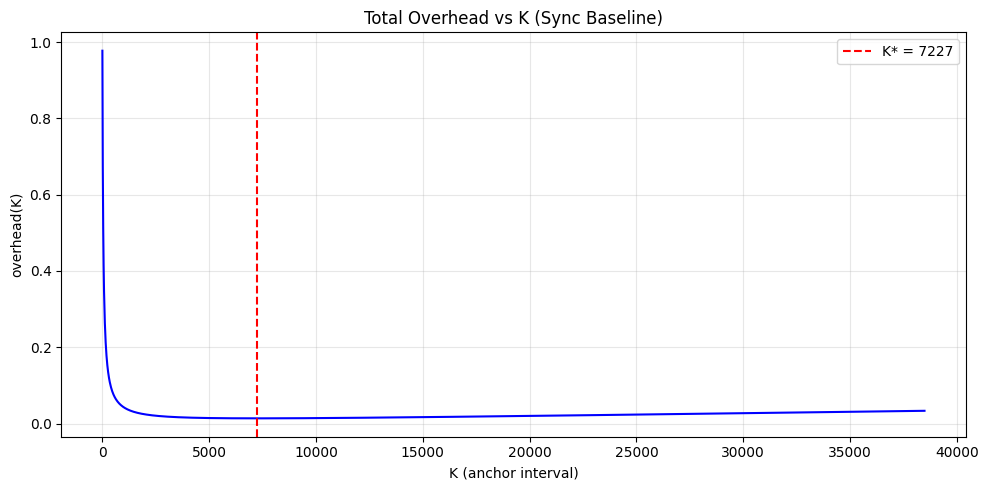

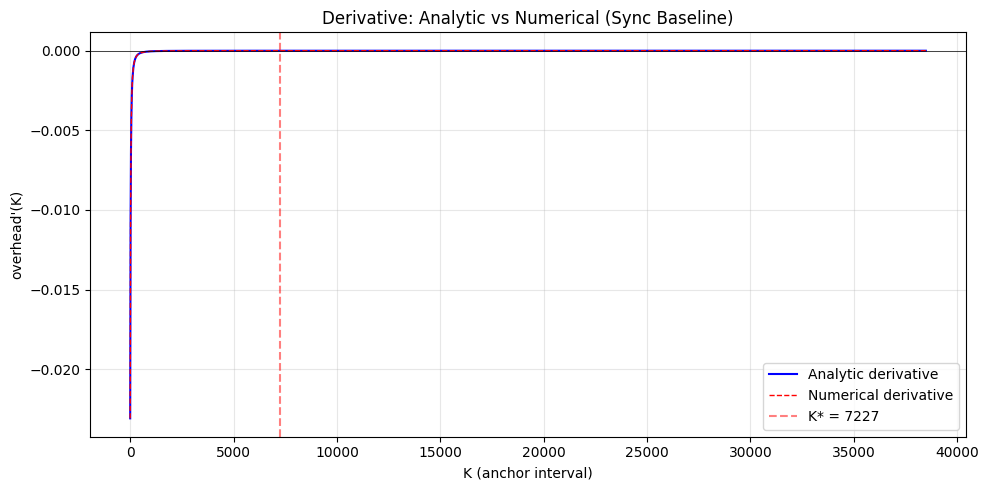

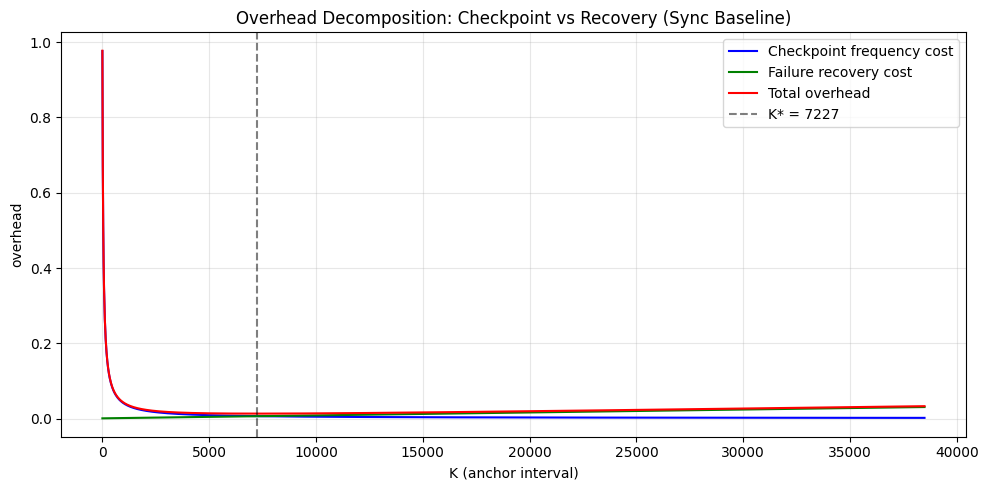

In [15]:


# Parameters
import numpy as np
from scipy.optimize import minimize_scalar, brentq
import matplotlib.pyplot as plt

# Hardware parameters (placeholder values — replace with real)
t_step   = 0.654       # GPU single-step training time (s)
t_l      = 8e-4     # log write time per step (s)
t        = t_step + t_l

t_d2h    = 2.0       # anchor D2H time (s)
t_persist= 25.0       # anchor persist time (s)
t_a      = t_d2h + t_persist  # full checkpoint time (blocks training)

t_r      = 0.06       # GPU single-step replay time (s)

L_disk   = 39.1      # load from disk to GPU (s)

MTBF_hours = 7.0     # mean time between failures (hours)
M = MTBF_hours * 3600 / t  # convert to steps

print(f"t = t_step + t_l = {t}")
print(f"t_a = t_d2h + t_persist = {t_a}")
print(f"M = {M:.0f} steps (MTBF = {MTBF_hours} h)")


def overhead_sync(K):
    """Total per-step overhead for sync baseline model."""
    T_cycle = K * t + t_a

    E_train = L_disk + t_r * K / 2
    E_ckpt  = L_disk + t_r * K

    E_recover = (K * t / T_cycle) * E_train + (t_a / T_cycle) * E_ckpt

    ckpt_cost = (K * t_l + t_a) / T_cycle
    recover_cost = E_recover / M

    return ckpt_cost + recover_cost


def overhead_sync_deriv(K):
    """Exact derivative d(overhead_sync)/dK."""
    T_cycle = K * t + t_a

    P_prime = -t_a * t_step / T_cycle**2

    G = (t_r * t / 2) * K**2 + K * (t * L_disk + t_a * t_r) + t_a * L_disk
    G_prime = t_r * t * K + t * L_disk + t_a * t_r

    Q_prime = (G_prime * T_cycle - G * t) / (M * T_cycle**2)

    return P_prime + Q_prime


def overhead_sync_deriv_numerical(K, h=1e-4):
    """Central difference numerical derivative for verification."""
    return (overhead_sync(K + h) - overhead_sync(K - h)) / (2 * h)

# Solve for K* — Method 1: minimize_scalar

K_min_bound = 1
K_max_bound = M

result1 = minimize_scalar(overhead_sync, bounds=(K_min_bound, K_max_bound), method='bounded')
K_star_method1 = result1.x

print(f"Method 1 (minimize_scalar):")
print(f"  K*           = {K_star_method1:.2f}")
print(f"  overhead(K*) = {result1.fun:.8f}")

# Solve for K* — Method 2: brentq on derivative

K_test = np.logspace(0, np.log10(K_max_bound), 1000)
derivs = [overhead_sync_deriv(K) for K in K_test]

K_star_method2 = None
for i in range(len(derivs) - 1):
    if derivs[i] * derivs[i + 1] < 0:
        K_star_method2 = brentq(overhead_sync_deriv, K_test[i], K_test[i + 1])
        break

if K_star_method2 is not None:
    print(f"Method 2 (brentq on derivative):")
    print(f"  K*           = {K_star_method2:.2f}")
    print(f"  overhead(K*) = {overhead_sync(K_star_method2):.8f}")
    print(f"  overhead'(K*)= {overhead_sync_deriv(K_star_method2):.2e}")
else:
    print("Method 2: No sign change found in derivative.")

# Cross-validate: analytic vs numerical derivative at K*

print(f"Derivative validation at K* = {K_star_method1:.2f}:")
print(f"  Analytic:  {overhead_sync_deriv(K_star_method1):.2e}")
print(f"  Numerical: {overhead_sync_deriv_numerical(K_star_method1):.2e}")

# Summary at optimal K*

K_star = K_star_method1
T_cycle_star = K_star * t + t_a

print(f"Optimal solution:")
print(f"  K*       = {K_star:.2f} steps")
print(f"  T_cycle  = {T_cycle_star:.2f} s")
print(f"  overhead = {overhead_sync(K_star)*100:.4f} %")

# Plot 1: overhead(K)

K_range = np.linspace(1, max(5000, K_max_bound), 2000)
oh_values = [overhead_sync(K) for K in K_range]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(K_range, oh_values, 'b-', linewidth=1.5)
ax.axvline(K_star, color='r', linestyle='--', label=f'K* = {K_star:.0f}')
ax.set_xlabel('K (anchor interval)')
ax.set_ylabel('overhead(K)')
ax.set_title('Total Overhead vs K (Sync Baseline)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Derivative — analytic vs numerical

deriv_analytic = [overhead_sync_deriv(K) for K in K_range]
deriv_numeric = [overhead_sync_deriv_numerical(K) for K in K_range]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(K_range, deriv_analytic, 'b-', linewidth=1.5, label='Analytic derivative')
ax.plot(K_range, deriv_numeric, 'r--', linewidth=1.0, label='Numerical derivative')
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(K_star, color='r', linestyle='--', alpha=0.5, label=f'K* = {K_star:.0f}')
ax.set_xlabel('K (anchor interval)')
ax.set_ylabel("overhead'(K)")
ax.set_title('Derivative: Analytic vs Numerical (Sync Baseline)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: Decomposed overhead — checkpoint cost vs recovery cost

def overhead_sync_decomposed(K):
    """Return (ckpt_cost, recover_cost) separately."""
    T_cycle = K * t + t_a
    E_train = L_disk + t_r * K / 2
    E_ckpt  = L_disk + t_r * K
    E_recover = (K * t / T_cycle) * E_train + (t_a / T_cycle) * E_ckpt
    ckpt_cost = (K * t_l + t_a) / T_cycle
    recover_cost = E_recover / M
    return ckpt_cost, recover_cost

ckpt_costs = []
recover_costs = []
for K in K_range:
    c, r = overhead_sync_decomposed(K)
    ckpt_costs.append(c)
    recover_costs.append(r)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(K_range, ckpt_costs, 'b-', linewidth=1.5, label='Checkpoint frequency cost')
ax.plot(K_range, recover_costs, 'g-', linewidth=1.5, label='Failure recovery cost')
ax.plot(K_range, oh_values, 'r-', linewidth=1.5, label='Total overhead')
ax.axvline(K_star, color='k', linestyle='--', alpha=0.5, label=f'K* = {K_star:.0f}')
ax.set_xlabel('K (anchor interval)')
ax.set_ylabel('overhead')
ax.set_title('Overhead Decomposition: Checkpoint vs Recovery (Sync Baseline)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **Evaluate**

In [4]:
!python3 /home/users/u0001609/NonStopZO2/experiments/analyze_checkpoint_time.py \
    /home/users/u0001609/ZO_log/r34.log \
    /home/users/u0001609/ZO_log/r35.log \
    /home/users/u0001609/ZO_log/r37.log \
    /home/users/u0001609/ZO_log/r38.log

Log file: /home/users/u0001609/ZO_log/r34.log
Train runtime (e2e): 112.7857s
Total checkpoints:  800
Average time:       0.0119s
Median time:        0.0120s
Standard deviation: 0.0051s
Total time spent:   9.5530s

Resume Information:
  [Resume Replay] 200 updates replayed in 4.127s (device=cuda)
  [Full Resume] Total checkpoint resume time: 12.462s
  [Full Resume] Total time from program start to first step: 115.491s

Log file: /home/users/u0001609/ZO_log/r35.log
Train runtime (e2e): 112.0184s
Total checkpoints:  800
Average time:       0.0116s
Median time:        0.0120s
Standard deviation: 0.0009s
Total time spent:   9.2770s

Resume Information:
  [Resume Replay] 200 updates replayed in 2.413s (device=cuda)
  [Full Resume] Total checkpoint resume time: 10.746s
  [Full Resume] Total time from program start to first step: 113.072s

Log file: /home/users/u0001609/ZO_log/r37.log
Train runtime (e2e): 117.8772s
Total checkpoints:  8
Average time:       0.0158s
Median time:        0.0140s
S

# **Plot**


  [Lustre / simulation]  Ca=30.287  U=0.0607  ts=0.128  tl=0.0120  Rf=131.1
    MTBF= 1h  →  K*=  4623.4  overhead=20.371%
    MTBF= 2h  →  K*=  6631.5  overhead=16.163%
    MTBF= 4h  →  K*=  9470.4  overhead=13.564%
    MTBF= 8h  →  K*= 13484.4  overhead=11.913%
    MTBF=12h  →  K*= 16564.3  overhead=11.232%
    MTBF=24h  →  K*= 23516.1  overhead=10.390%

  [SSD / simulation]  Ca=8.004  U=0.0614  ts=0.128  tl=0.0030  Rf=109.0
    MTBF= 1h  →  K*=  2583.2  overhead=9.831%
    MTBF= 2h  →  K*=  3678.9  overhead=6.996%
    MTBF= 4h  →  K*=  5228.5  overhead=5.304%
    MTBF= 8h  →  K*=  7419.7  overhead=4.265%
    MTBF=12h  →  K*=  9101.1  overhead=3.846%
    MTBF=24h  →  K*= 12896.4  overhead=3.338%

  [DRAM / simulation]  Ca=1.912  U=0.0614  ts=0.128  tl=0.0020  Rf=109.9
    MTBF= 1h  →  K*=  1287.9  overhead=6.816%
    MTBF= 2h  →  K*=  1827.6  overhead=4.638%
    MTBF= 4h  →  K*=  2590.7  overhead=3.414%
    MTBF= 8h  →  K*=  3670.0  overhead=2.706%
    MTBF=12h  →  K*=  4498.1  over

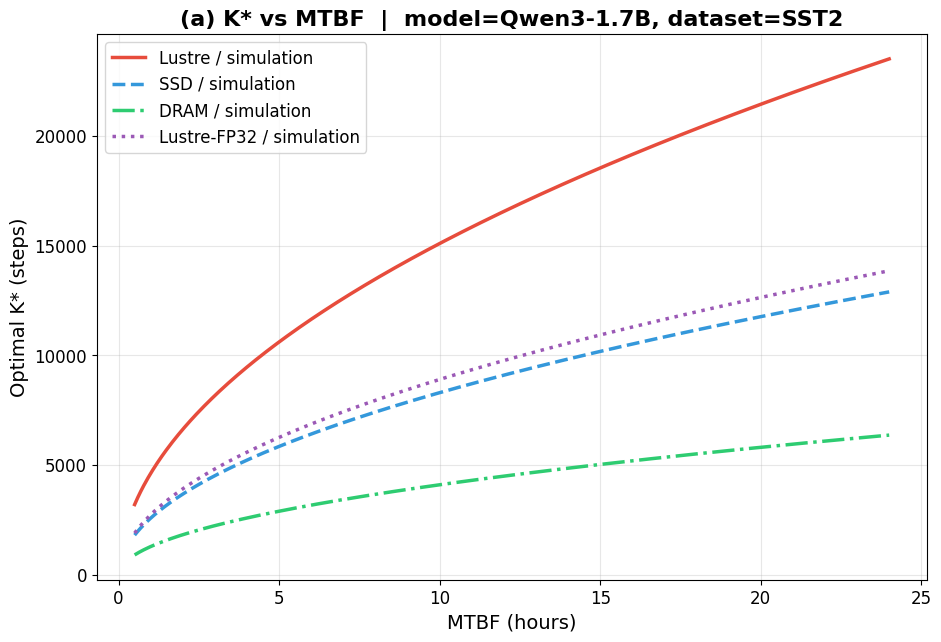

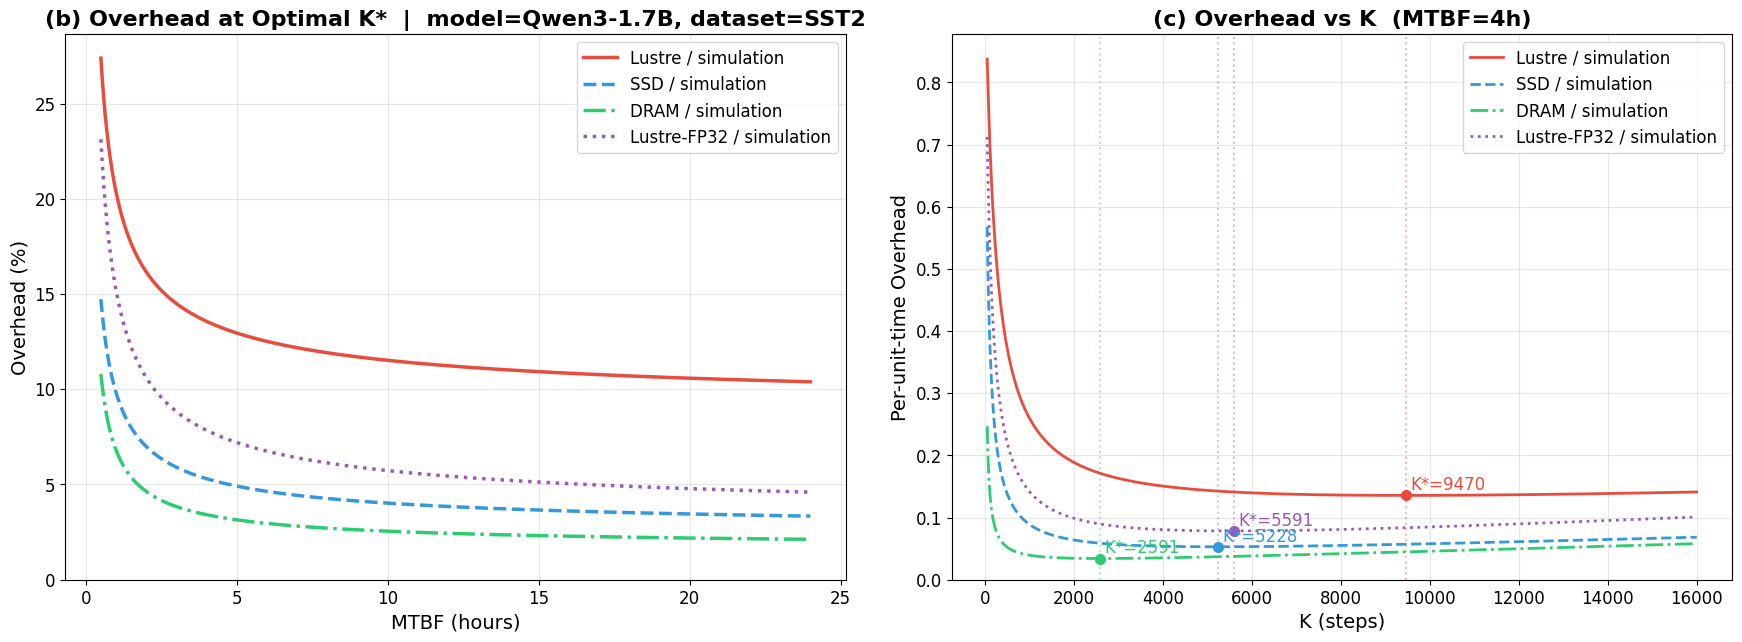

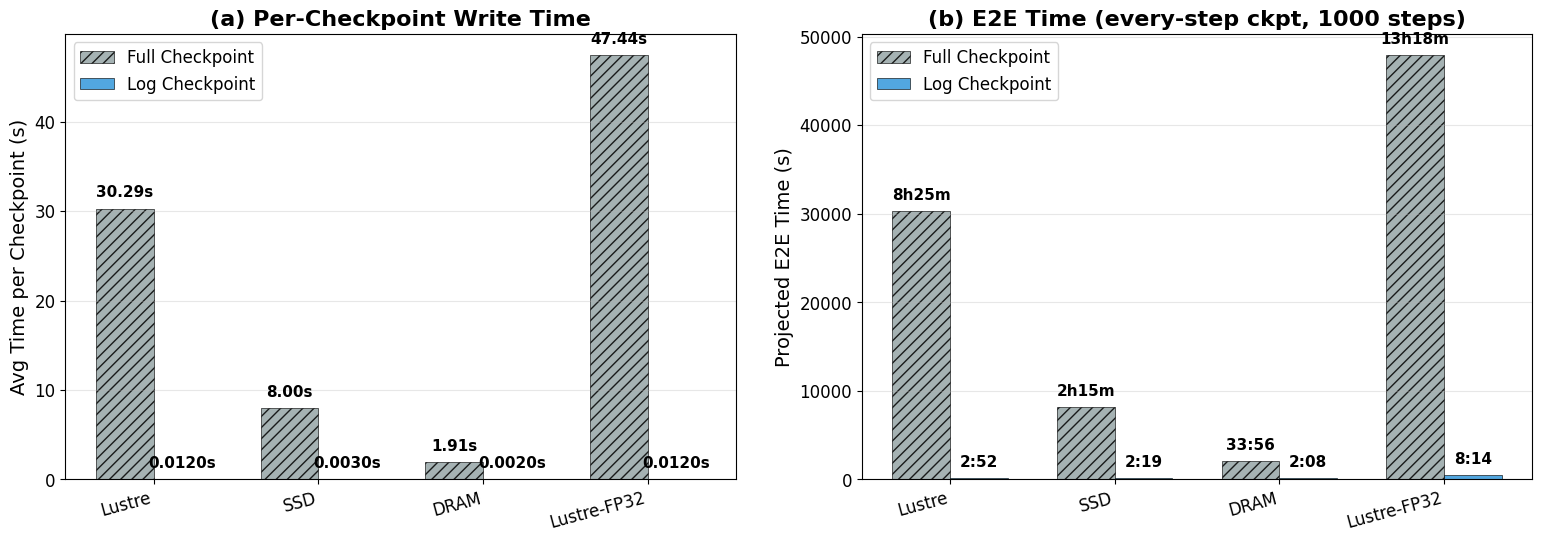

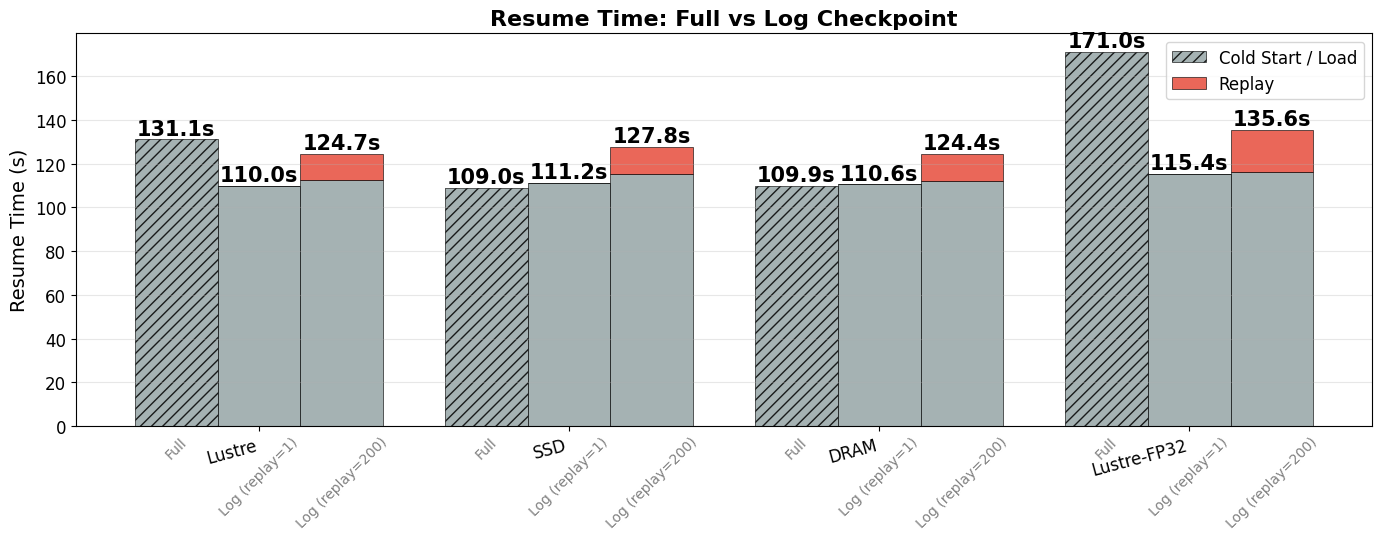

In [ ]:
"""
ZO Checkpoint 成本模型 — 数据 + 画图配置
==========================================
只需要填测量数据和配置参数，其他全部自动计算。
数据按 "Model / Dataset" → FS 分组。
"""

import sys
import importlib
sys.path.insert(0, '/home/users/u0001609/NonStopZO2/experiments')

import zo_optimal_K_model
importlib.reload(zo_optimal_K_model)
from zo_optimal_K_model import (
    plot_cost_model,
    plot_e2e_comparison,
    plot_resume_comparison,
)
import matplotlib.pyplot as plt

# ╔══════════════════════════════════════════════════════════════╗
# ║                    在这里填测量数据                            ║
# ╚══════════════════════════════════════════════════════════════╝

EXPERIMENTS = {
    # ==================== Qwen3-1.7B / SST2 ====================
    "Qwen3-1.7B / SST2": {
        "ts": 0.128,        # 每步训练时间 (秒)
        "total_steps": 1000,
        "Info": [
            {
                "FS": "Lustre",
                "avg_full_ckpt_time": 30.287,
                "avg_log_ckpt_time": 0.012,
                "e2e_train": [
                {"checkpoint_type": "full", "checkpoint numbers": 10, "e2e_time_seconds": 330.764,},
                {"checkpoint_type": "log", "checkpoint numbers": 1000, "e2e_time_seconds": 172.607,},
                ],
                "full checkpoint resume time": 131.108,
                "log checkpoint resume time": {"type": "simulation", "data": [
                    {"replay_steps": 1, "replay_time": 8.907, "total_resume_time": 110.024},
                    {"replay_steps": 200, "replay_time": 20.982, "total_resume_time": 124.650}]
                    }
            },
            {
                "FS": "SSD",
                "avg_full_ckpt_time": 8.004,
                "avg_log_ckpt_time": 0.003,
                "e2e_train": [
                {"checkpoint_type": "full", "checkpoint numbers": 10, "e2e_time_seconds": 208.666,},
                {"checkpoint_type": "log", "checkpoint numbers": 1000, "e2e_time_seconds": 139.454,},
                ],
                "full checkpoint resume time": 109.013,
                "log checkpoint resume time": {"type": "simulation", "data": [
                    {"replay_steps": 1, "replay_time": 0.381, "total_resume_time": 111.155},
                    {"replay_steps": 200, "replay_time": 12.608, "total_resume_time": 127.811}]
                    }
            },
            {
                "FS": "DRAM",
                "avg_full_ckpt_time": 1.912,
                "avg_log_ckpt_time": 0.002,
                "e2e_train": [
                {"checkpoint_type": "full", "checkpoint numbers": 10, "e2e_time_seconds": 143.663,},
                {"checkpoint_type": "log", "checkpoint numbers": 1000, "e2e_time_seconds": 128.989,},
                ],
                "full checkpoint resume time": 109.947,
                "log checkpoint resume time": {"type": "simulation", "data": [
                    {"replay_steps": 1, "replay_time": 0.387, "total_resume_time": 110.570},
                    {"replay_steps": 200, "replay_time": 12.613, "total_resume_time": 124.360}]
                    }
            },
            # {
            #     "FS": "CPU",
            #     "avg_full_ckpt_time": 20.997,
            #     "avg_log_ckpt_time": 0.012,
            #     "e2e_train": [
            #     {"checkpoint_type": "full", "checkpoint numbers": 10, "e2e_time_seconds": 330.764,},
            #     {"checkpoint_type": "log", "checkpoint numbers": 1000, "e2e_time_seconds": 172.607,},
            #     ],
            #     "full checkpoint resume time": 131.108,
            #     "log checkpoint resume time": {"type": "simulation", "data": [
            #         {"replay_steps": 1, "replay_time": 15.417, "total_resume_time": 117.986},
            #         {"replay_steps": 200, "replay_time": 1467.460, "total_resume_time": 1566.332}]
            #         }
            # },
            {
                "FS": "Async-Lustre",
                "avg_full_ckpt_time": 0.005,
                "avg_log_ckpt_time": 0.002,
                "n_lag": 237,   
                "e2e_train": [
                {"checkpoint_type": "full", "checkpoint numbers": 10, "e2e_time_seconds": 330.764,},
                {"checkpoint_type": "log", "checkpoint numbers": 1000, "e2e_time_seconds": 172.607,},
                ],
                "full checkpoint resume time": 131.108,
                "log checkpoint resume time": {"type": "simulation", "data": [
                    {"replay_steps": 1, "replay_time": 8.907, "total_resume_time": 110.024},
                    {"replay_steps": 200, "replay_time": 20.982, "total_resume_time": 124.650}]
                    }
            },
            {
                "FS": "Async-SSD",
                "avg_full_ckpt_time": 0.003,
                "avg_log_ckpt_time": 0.001,
                "n_lag": 63,
                "e2e_train": [
                {"checkpoint_type": "async", "checkpoint numbers": 1000, "e2e_time_seconds": 128.629,},
                ],
                "full checkpoint resume time": 109.013,
                "log checkpoint resume time": {"type": "simulation", "data": [
                    {"replay_steps": 1, "replay_time": 0.381, "total_resume_time": 111.155},
                    {"replay_steps": 200, "replay_time": 12.608, "total_resume_time": 127.811}]
                    }
            },
        ],
    },
    # ==================== Qwen3-1.7B / SST2 / FP32 ====================
    "Qwen3-1.7B / SST2-FP32": {
        "ts": 0.411,        # 每步训练时间 (秒)
        "total_steps": 1000,
        "Info": [
            {
                "FS": "Lustre-FP32",
                "avg_full_ckpt_time": 47.436,
                "avg_log_ckpt_time": 0.012,
                "e2e_train": [
                {"checkpoint_type": "full", "checkpoint numbers": 10, "e2e_time_seconds": 921.767,},
                {"checkpoint_type": "log", "checkpoint numbers": 1000, "e2e_time_seconds": 494.850,},
                ],
                "full checkpoint resume time": 170.977,
                "log checkpoint resume time": [
                    {"type": "simulation", "data": [
                        {"replay_steps": 1, "replay_time": 0.414, "total_resume_time": 115.381},
                        {"replay_steps": 200, "replay_time": 19.608, "total_resume_time": 135.568}]
                    },
                ]
            },
        ],
    },

    # ==================== Qwen3-1.7B / SQuAD ====================
    "Qwen3-1.7B / SQuAD": {
        "ts": 0.242,        # 每步训练时间 (秒)
        "total_steps": 1000,
        "Info": [
            {
                "FS": "Lustre",
                "avg_full_ckpt_time": 20.894,
                "avg_log_ckpt_time": 0.071,
                "e2e_train": [
                {"checkpoint_type": "full", "checkpoint numbers": 10, "e2e_time_seconds": 499.3334,},
                {"checkpoint_type": "log", "checkpoint numbers": 1000, "e2e_time_seconds": 366.092,},
                ],
                # TODO: 补充 "full checkpoint resume time"
                "log checkpoint resume time": [
                    {"type": "simulation", "data": [
                        {"replay_steps": 1, "replay_time": 0.386, "total_resume_time": 8.299},
                        {"replay_steps": 100, "replay_time": 7.325, "total_resume_time": 15.080}]
                    },
                    {"type": "no-simulation", "data": [
                        {"replay_steps": 1, "replay_time": 0.828, "total_resume_time": 8.786},
                        {"replay_steps": 100, "replay_time": 2.602, "total_resume_time": 10.456}]
                    },
                ]
            },
        ],
    },

    # ==================== Qwen3-8B / SST2 ====================
    "Qwen3-8B / SST2": {
        "ts": 0.443,        # 每步训练时间 (秒)
        "total_steps": 1000,
        "Info": [
            {
                "FS": "Lustre",
                "avg_full_ckpt_time": 134.751,
                "avg_log_ckpt_time": 0.020,
                "e2e_train": [
                {"checkpoint_type": "full", "checkpoint numbers": 10, "e2e_time_seconds": 1790.513,},
                {"checkpoint_type": "log", "checkpoint numbers": 1000, "e2e_time_seconds": 2465.772,},
                ],
                # TODO: 补充 "full checkpoint resume time"
                "log checkpoint resume time": [
                    {"type": "simulation", "data": [
                        {"replay_steps": 1, "replay_time": 0.598, "total_resume_time": 16.323},
                        {"replay_steps": 100, "replay_time": 27.449, "total_resume_time": 42.279}]
                    },
                    {"type": "no-simulation", "data": [
                        {"replay_steps": 1, "replay_time": 0.416, "total_resume_time": 15.380},
                        {"replay_steps": 100, "replay_time": 8.893, "total_resume_time": 24.457}]
                    },
                ]
            },
        ],
    },
}

# ========== MTBF 配置 ==========
MTBF_CONFIG = {
    "range_hours": (0.5, 24),
    "demo_hours": 4,
    "table_values": [1, 2, 4, 8, 12, 24],
}

# ╔══════════════════════════════════════════════════════════════╗
# ║                    Plot 配置                                  ║
# ╚══════════════════════════════════════════════════════════════╝

# --- Plot 1: Cost Model (3 subplots: K* vs MTBF, Overhead%, Overhead vs K) ---
# 可选维度: model, dataset, FS, simulation
# 设为具体值 → 固定该维度 (只画匹配的数据); 设为 None → 该维度每个值各画一条线
# 例: model="Qwen3-1.7B", dataset="SST2", FS=None, simulation=None
#     → 画 Qwen3-1.7B/SST2 的所有 FS × simulation 组合
PLOT1_CONFIG = {
    "model": "Qwen3-1.7B",      # "Qwen3-1.7B" / "Qwen3-8B" / None
    "dataset": "SST2",           # "SST2" / "SQuAD" / None
    "FS": None,                  # "Lustre" / "Local SSD" / "DRAM" / None
    "simulation": None,          # "simulation" / "no-simulation" / None
}


# --- Plot 2: E2E Comparison (Full vs Log, 归一化为每步 ckpt 1 次) ---
# group_by: x 轴分组维度，3 选 1: "model" / "dataset" / "FS"
# 其他两个维度用于过滤 (设为具体值过滤, None = 不过滤)
# 归一化公式: pure_train = e2e - avg_ckpt × num_ckpts;
#            projected = pure_train + avg_ckpt × total_steps
PLOT2_CONFIG = {
    "group_by": "FS",            # x 轴分组: "model" / "dataset" / "FS"
    "model": "Qwen3-1.7B",      # 过滤 (当 group_by != "model" 时生效)
    "dataset": "SST2",           # 过滤 (当 group_by != "dataset" 时生效)
}

# --- Plot 3: Resume Time (Full vs Log, stacked bar) ---
# group_by: x 轴分组维度，3 选 1: "model" / "dataset" / "FS"
# simulation: 过滤 log resume 类型 ("simulation" / "no-simulation" / None=全部)
# Log bar 分两段: 底部=cold_start/load, 顶部=replay (U*replay_steps)
# total_resume_time 直接用提供的数据; U 由所有数据点 polyfit 拟合
PLOT3_CONFIG = {
    "group_by": "FS",            # x 轴分组: "model" / "dataset" / "FS"
    "model": "Qwen3-1.7B",      # 过滤
    "dataset": "SST2",           # 过滤
    "simulation": "simulation",  # "simulation" / "no-simulation" / None
}

# ╔══════════════════════════════════════════════════════════════╗
# ║                       画图                                    ║
# ╚══════════════════════════════════════════════════════════════╝

plot_cost_model(EXPERIMENTS, PLOT1_CONFIG, MTBF_CONFIG)
plot_e2e_comparison(EXPERIMENTS, PLOT2_CONFIG)
plot_resume_comparison(EXPERIMENTS, PLOT3_CONFIG)

plt.show()

In [1]:
!lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             52 bits physical, 57 bits virtual
  Byte Order:                Little Endian
CPU(s):                      192
  On-line CPU(s) list:       0-191
Vendor ID:                   AuthenticAMD
  Model name:                AMD EPYC 9684X 96-Core Processor
    CPU family:              25
    Model:                   17
    Thread(s) per core:      2
    Core(s) per socket:      96
    Socket(s):               1
    Stepping:                2
    Frequency boost:         enabled
    CPU(s) scaling MHz:      70%
    CPU max MHz:             3716.8860
    CPU min MHz:             1500.0000
    BogoMIPS:                5099.99
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ht s
                             yscall nx mmxext fxsr_opt pdpe1gb rdtscp lm constan
                         

# **Legacy Diagram**

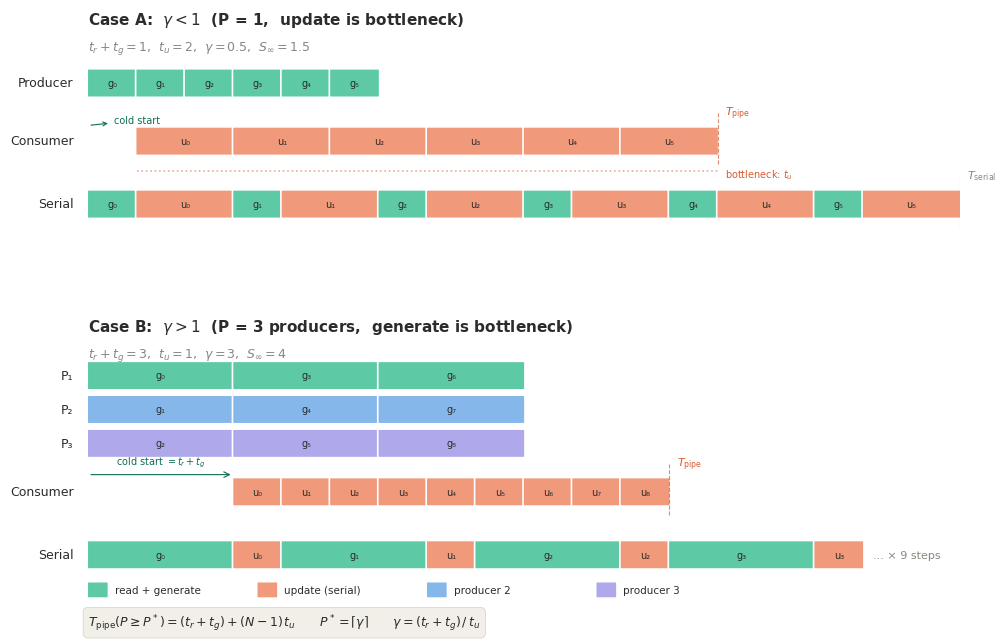

In [ ]:
"""
Pipeline replay timeline diagrams for ZO checkpoint recovery.
Generates two figures:
  Case A: γ < 1 (t_g < t_u), P=1 producer, update is bottleneck
  Case B: γ > 1 (t_g > t_u), P=3 producers, generate is bottleneck

Output: pipeline_replay_timelines.pdf (one page, two subplots stacked)
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

# ── Color palette ──
C_GEN = "#5DCAA5"       # teal - read+generate
C_GEN2 = "#85B7EB"      # blue - producer 2
C_GEN3 = "#AFA9EC"      # purple - producer 3
C_UPD = "#F0997B"       # coral - update
C_IDLE = "#D3D1C7"      # gray - idle/wait
C_TEXT = "#2C2C2A"
C_MUTED = "#888780"
C_ACCENT = "#D85A30"    # bottleneck indicator

def draw_block(ax, x, y, w, h, color, label="", fontsize=8, text_color="white"):
    """Draw a rounded rectangle block with centered label."""
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02",
                         facecolor=color, edgecolor="white", linewidth=1.2)
    ax.add_patch(box)
    if label:
        ax.text(x + w/2, y + h/2, label, ha="center", va="center",
                fontsize=fontsize, color=text_color, fontweight="medium",
                fontfamily="sans-serif")

def subscript(n):
    """Return unicode subscript for integer n."""
    subs = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")
    return str(n).translate(subs)

def draw_brace_below(ax, x1, x2, y, label, color=C_MUTED):
    """Draw a small horizontal brace annotation below the timeline."""
    mid = (x1 + x2) / 2
    ax.annotate("", xy=(x1, y), xytext=(x2, y),
                arrowprops=dict(arrowstyle="<->", color=color, lw=0.8))
    ax.text(mid, y - 0.15, label, ha="center", va="top",
            fontsize=7, color=color, fontstyle="italic")

# ── Figure setup ──
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6.5))
for ax in (ax1, ax2):
    ax.set_xlim(-0.5, 18)
    ax.set_ylim(-1.5, 4.5)
    ax.set_aspect("equal")
    ax.axis("off")

# ════════════════════════════════════════════
# CASE A: γ < 1, P = 1
# t_r + t_g = 1 unit, t_u = 2 units, γ = 0.5
# ════════════════════════════════════════════
ax = ax1
tg = 1.0   # read + generate
tu = 2.0   # update
N = 6
bh = 0.55  # block height

ax.text(0, 4.2, r"Case A:  $\gamma < 1$  (P = 1,  update is bottleneck)",
        fontsize=11, fontweight="bold", color=C_TEXT, fontfamily="sans-serif")
ax.text(0, 3.65, r"$t_r + t_g = 1$,  $t_u = 2$,  $\gamma = 0.5$,  $S_\infty = 1.5$",
        fontsize=9, color=C_MUTED, fontfamily="sans-serif")

# Lane labels
labels_y = {"Producer": 2.7, "Consumer": 1.5, "Serial": 0.2}
for lbl, yy in labels_y.items():
    ax.text(-0.3, yy + bh/2, lbl, ha="right", va="center",
            fontsize=9, fontweight="medium", color=C_TEXT)

# Producer lane: continuous generation
x = 0
for i in range(N):
    draw_block(ax, x, labels_y["Producer"], tg, bh, C_GEN, f"g{subscript(i)}", 7, C_TEXT)
    x += tg

# Consumer lane: starts after cold start, each tu wide
x = tg  # cold start
for i in range(N):
    draw_block(ax, x, labels_y["Consumer"], tu, bh, C_UPD, f"u{subscript(i)}", 7, C_TEXT)
    x += tu

# Cold start annotation
ax.annotate("cold start", xy=(0, labels_y["Consumer"] + bh + 0.05),
            xytext=(tg, labels_y["Consumer"] + bh + 0.05),
            fontsize=7, color="#0F6E56", va="bottom", ha="center",
            arrowprops=dict(arrowstyle="<-", color="#0F6E56", lw=0.8))

# Serial baseline
x = 0
for i in range(N):
    draw_block(ax, x, labels_y["Serial"], tg, bh, C_GEN, f"g{subscript(i)}", 7, C_TEXT)
    x += tg
    draw_block(ax, x, labels_y["Serial"], tu, bh, C_UPD, f"u{subscript(i)}", 7, C_TEXT)
    x += tu

# End markers
t_pipe = tg + N * tu
t_serial = N * (tg + tu)
ax.plot([t_pipe, t_pipe], [labels_y["Consumer"] - 0.2, labels_y["Consumer"] + bh + 0.3],
        ls="--", lw=0.8, color=C_ACCENT, alpha=0.7)
ax.text(t_pipe + 0.15, labels_y["Consumer"] + bh + 0.25,
        r"$T_{\mathrm{pipe}}$", fontsize=8, color=C_ACCENT)
ax.plot([t_serial, t_serial], [labels_y["Serial"] - 0.2, labels_y["Serial"] + bh + 0.3],
        ls="--", lw=0.8, color=C_MUTED, alpha=0.7)
ax.text(t_serial + 0.15, labels_y["Serial"] + bh + 0.25,
        r"$T_{\mathrm{serial}}$", fontsize=8, color=C_MUTED)

# Bottleneck line
ax.plot([tg, t_pipe], [labels_y["Consumer"] - 0.35, labels_y["Consumer"] - 0.35],
        ls=":", lw=1.2, color=C_ACCENT, alpha=0.5)
ax.text(t_pipe + 0.15, labels_y["Consumer"] - 0.4,
        r"bottleneck: $t_u$", fontsize=7, color=C_ACCENT, va="center")


# ════════════════════════════════════════════
# CASE B: γ > 1, P = 3
# t_r + t_g = 3 units, t_u = 1 unit, γ = 3
# ════════════════════════════════════════════
ax = ax2
tg = 3.0
tu = 1.0
P = 3
N = 9

ax.text(0, 4.2, r"Case B:  $\gamma > 1$  (P = 3 producers,  generate is bottleneck)",
        fontsize=11, fontweight="bold", color=C_TEXT, fontfamily="sans-serif")
ax.text(0, 3.65, r"$t_r + t_g = 3$,  $t_u = 1$,  $\gamma = 3$,  $S_\infty = 4$",
        fontsize=9, color=C_MUTED, fontfamily="sans-serif")

# Lane labels
labels_y = {"P₁": 3.0, "P₂": 2.3, "P₃": 1.6, "Consumer": 0.6, "Serial": -0.7}
for lbl, yy in labels_y.items():
    ax.text(-0.3, yy + bh/2, lbl, ha="right", va="center",
            fontsize=9, fontweight="medium", color=C_TEXT)

colors_p = [C_GEN, C_GEN2, C_GEN3]
lane_keys = ["P₁", "P₂", "P₃"]

# Producers: all start at t=0, each generates z's round-robin
# P_k generates z_k, z_{k+P}, z_{k+2P}, ...
for k in range(P):
    x = 0
    step = k
    while step < N:
        draw_block(ax, x, labels_y[lane_keys[k]], tg, bh, colors_p[k],
                   f"g{subscript(step)}", 7, C_TEXT)
        x += tg
        step += P

# Consumer: z0 ready at t = tg (first z done), then one per tu
# But supply rate = tg/P = 1 per unit, demand rate = 1 per tu = 1 per unit → balanced
x_consumer = tg  # cold start: wait for first z
for i in range(N):
    draw_block(ax, x_consumer, labels_y["Consumer"], tu, bh, C_UPD,
               f"u{subscript(i)}", 7, C_TEXT)
    x_consumer += tu

# Cold start annotation
ax.annotate("", xy=(0, labels_y["Consumer"] + bh + 0.08),
            xytext=(tg, labels_y["Consumer"] + bh + 0.08),
            arrowprops=dict(arrowstyle="<-", color="#0F6E56", lw=0.8))
ax.text(tg / 2, labels_y["Consumer"] + bh + 0.2, r"cold start $= t_r + t_g$",
        ha="center", va="bottom", fontsize=7, color="#0F6E56")

# Serial baseline
x = 0
for i in range(min(N, 4)):  # only draw 4 to fit
    draw_block(ax, x, labels_y["Serial"], tg, bh, C_GEN, f"g{subscript(i)}", 7, C_TEXT)
    x += tg
    draw_block(ax, x, labels_y["Serial"], tu, bh, C_UPD, f"u{subscript(i)}", 7, C_TEXT)
    x += tu
ax.text(x + 0.2, labels_y["Serial"] + bh/2, f"... × {N} steps",
        fontsize=8, color=C_MUTED, va="center")

# End markers
t_pipe = tg + N * tu
ax.plot([t_pipe, t_pipe], [labels_y["Consumer"] - 0.2, labels_y["Consumer"] + bh + 0.3],
        ls="--", lw=0.8, color=C_ACCENT, alpha=0.7)
ax.text(t_pipe + 0.15, labels_y["Consumer"] + bh + 0.25,
        r"$T_{\mathrm{pipe}}$", fontsize=8, color=C_ACCENT)

# Legend
legend_y = -1.3
legend_items = [(C_GEN, "read + generate"), (C_UPD, "update (serial)"),
                (C_GEN2, "producer 2"), (C_GEN3, "producer 3")]
x_leg = 0
for color, label in legend_items:
    draw_block(ax, x_leg, legend_y, 0.4, 0.3, color)
    ax.text(x_leg + 0.55, legend_y + 0.15, label, fontsize=7.5,
            color=C_TEXT, va="center")
    x_leg += 3.5

# Formula box at bottom
ax.text(0, legend_y - 0.6,
        r"$T_{\mathrm{pipe}}(P \geq P^*) = (t_r + t_g) + (N-1)\,t_u$"
        r"$\qquad P^* = \lceil\gamma\rceil$"
        r"$\qquad \gamma = (t_r + t_g)\,/\,t_u$",
        fontsize=9, color=C_TEXT, fontfamily="sans-serif",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#F1EFE8", edgecolor="#D3D1C7", lw=0.5))

plt.tight_layout(pad=1.0)

(-1.7999999999999998, 8.4)

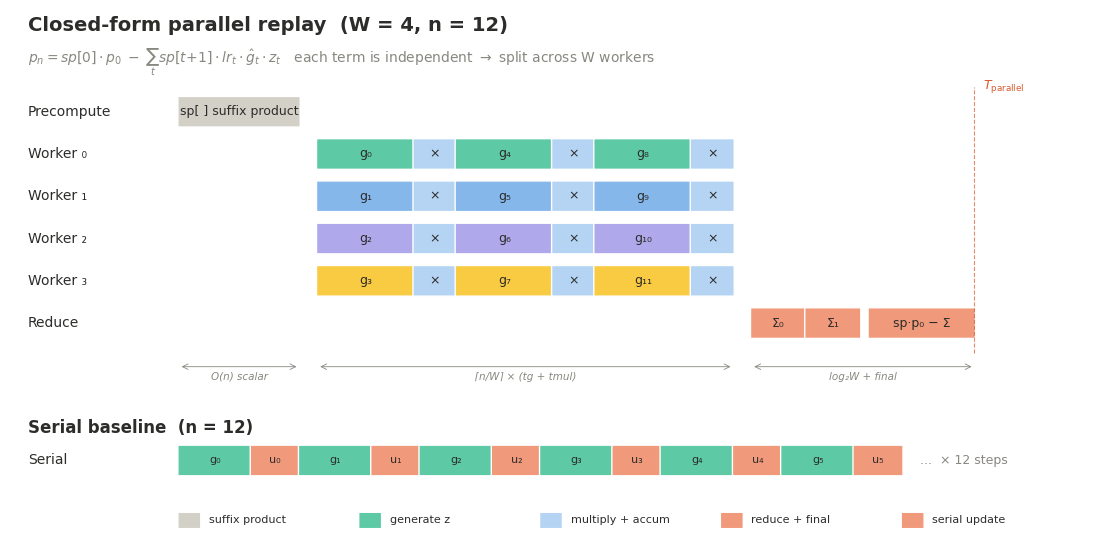

In [ ]:
"""
Closed-form parallel replay timeline diagram for ZO checkpoint recovery.
Single canvas, no subplots, tight layout.

Output: closed_form_replay_timeline.pdf / .png
"""

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np


def subscript(n):
    subs = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")
    return str(n).translate(subs)


# ── Color palette ──
C_SP   = "#D3D1C7"
C_GEN  = "#5DCAA5"
C_GEN2 = "#85B7EB"
C_GEN3 = "#AFA9EC"
C_GEN4 = "#F9CB42"
C_MUL  = "#B5D4F4"
C_RED  = "#F0997B"
C_SERIAL_G = "#5DCAA5"
C_SERIAL_U = "#F0997B"
C_TEXT = "#2C2C2A"
C_MUTED = "#888780"
C_ACCENT = "#D85A30"


def draw_block(ax, x, y, w, h, color, label="", fontsize=8, text_color=None):
    if text_color is None:
        text_color = C_TEXT
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.015",
                         facecolor=color, edgecolor="white", linewidth=1.0)
    ax.add_patch(box)
    if label:
        ax.text(x + w/2, y + h/2, label, ha="center", va="center",
                fontsize=fontsize, color=text_color, fontweight="medium",
                fontfamily="sans-serif")


# ── Parameters ──
W = 4
n = 12
bh = 0.55
lane_gap = 0.8

t_sp = 2.0
t_gen = 1.6
t_mul = 0.7
t_reduce = 0.9
t_serial_g = 1.2
t_serial_u = 0.8

steps_per_worker = int(np.ceil(n / W))
worker_colors = [C_GEN, C_GEN2, C_GEN3, C_GEN4]

# ── Single figure, single axes ──
fig, ax = plt.subplots(1, 1, figsize=(14, 7))
ax.axis("off")

top_y = 8.0
x_start = 2.5

# ── Title ──
ax.text(0, top_y, f"Closed-form parallel replay  (W = {W}, n = {n})",
        fontsize=14, fontweight="bold", color=C_TEXT)
ax.text(0, top_y - 0.6,
        r"$p_n = sp[0] \cdot p_0 \;-\; \sum_t sp[t\!+\!1] \cdot lr_t \cdot \hat{g}_t \cdot z_t$"
        r"$\quad$each term is independent $\rightarrow$ split across W workers",
        fontsize=10, color=C_MUTED)

# ── Precompute lane ──
sp_y = top_y - 1.8
ax.text(0, sp_y + bh/2, "Precompute", ha="left", va="center",
        fontsize=10, fontweight="medium", color=C_TEXT)
draw_block(ax, x_start, sp_y, t_sp, bh, C_SP, "sp[ ] suffix product", 9)

# ── Worker lanes ──
for k in range(W):
    lane_y = sp_y - (k + 1) * lane_gap
    ax.text(0, lane_y + bh/2, f"Worker {subscript(k)}", ha="left", va="center",
            fontsize=10, fontweight="medium", color=C_TEXT)

    x = x_start + t_sp + 0.3
    assigned = list(range(k, n, W))
    for step in assigned:
        draw_block(ax, x, lane_y, t_gen, bh, worker_colors[k],
                   f"g{subscript(step)}", 9)
        x += t_gen
        draw_block(ax, x, lane_y, t_mul, bh, C_MUL, "×", 9)
        x += t_mul

# ── Reduce lane ──
reduce_y = sp_y - (W + 1) * lane_gap
ax.text(0, reduce_y + bh/2, "Reduce", ha="left", va="center",
        fontsize=10, fontweight="medium", color=C_TEXT)

worker_end_x = x_start + t_sp + 0.3 + steps_per_worker * (t_gen + t_mul)
n_reduce_steps = int(np.ceil(np.log2(W)))
rx = worker_end_x + 0.3
for r in range(n_reduce_steps):
    draw_block(ax, rx, reduce_y, t_reduce, bh, C_RED, f"Σ{subscript(r)}", 9)
    rx += t_reduce
draw_block(ax, rx + 0.15, reduce_y, t_mul * 2.5, bh, C_RED, "sp·p₀ − Σ", 9)
total_parallel = rx + 0.15 + t_mul * 2.5

# End marker
ax.plot([total_parallel, total_parallel],
        [reduce_y - 0.3, sp_y + bh + 0.2],
        ls="--", lw=0.8, color=C_ACCENT, alpha=0.7)
ax.text(total_parallel + 0.15, sp_y + bh + 0.15,
        r"$T_{\mathrm{parallel}}$", fontsize=9, color=C_ACCENT)

# Phase annotations
brace_y = reduce_y - 0.55
ax.annotate("", xy=(x_start, brace_y), xytext=(x_start + t_sp, brace_y),
            arrowprops=dict(arrowstyle="<->", color=C_MUTED, lw=0.6))
ax.text(x_start + t_sp/2, brace_y - 0.25, "O(n) scalar", ha="center",
        fontsize=7.5, color=C_MUTED, fontstyle="italic")

par_s = x_start + t_sp + 0.3
par_e = worker_end_x
ax.annotate("", xy=(par_s, brace_y), xytext=(par_e, brace_y),
            arrowprops=dict(arrowstyle="<->", color=C_MUTED, lw=0.6))
ax.text((par_s + par_e)/2, brace_y - 0.25, "⌈n/W⌉ × (tg + tmul)",
        ha="center", fontsize=7.5, color=C_MUTED, fontstyle="italic")

ax.annotate("", xy=(worker_end_x + 0.3, brace_y),
            xytext=(total_parallel, brace_y),
            arrowprops=dict(arrowstyle="<->", color=C_MUTED, lw=0.6))
ax.text((worker_end_x + 0.3 + total_parallel)/2, brace_y - 0.25,
        "log₂W + final", ha="center", fontsize=7.5, color=C_MUTED,
        fontstyle="italic")

# ── Serial baseline ──
serial_title_y = reduce_y - 1.8
ax.text(0, serial_title_y, f"Serial baseline  (n = {n})",
        fontsize=12, fontweight="bold", color=C_TEXT)

serial_y = serial_title_y - 0.8
ax.text(0, serial_y + bh/2, "Serial", ha="left", va="center",
        fontsize=10, fontweight="medium", color=C_TEXT)

x = x_start
shown = 6
for i in range(shown):
    draw_block(ax, x, serial_y, t_serial_g, bh, C_SERIAL_G,
               f"g{subscript(i)}", 8)
    x += t_serial_g
    draw_block(ax, x, serial_y, t_serial_u, bh, C_SERIAL_U,
               f"u{subscript(i)}", 8)
    x += t_serial_u

ax.text(x + 0.3, serial_y + bh/2, f"...  × {n} steps",
        fontsize=9, color=C_MUTED, va="center")

# ── Legend ──
leg_y = serial_y - 1.0
items = [
    (C_SP, "suffix product"),
    (C_GEN, "generate z"),
    (C_MUL, "multiply + accum"),
    (C_RED, "reduce + final"),
    (C_SERIAL_U, "serial update"),
]
x_leg = x_start
for color, label in items:
    draw_block(ax, x_leg, leg_y, 0.35, 0.28, color)
    ax.text(x_leg + 0.5, leg_y + 0.14, label, fontsize=8,
            color=C_TEXT, va="center")
    x_leg += 3.0

# ── Set limits tight ──
ax.set_xlim(-0.3, max(total_parallel, x) + 2)
ax.set_ylim(leg_y - 0.4, top_y + 0.4)